# TCC - Análise da Produção e Faturamento de Mel no Brasil

## 1. Introdução

**Autor**: Gabriel de Jesus.

O mel, um produto natural de grande valor nutritivo e econômico, desempenha um papel significativo na economia agrícola brasileira. A apicultura, atividade responsável pela sua produção, contribui para a renda de milhares de famílias e é vital para a polinização de diversas culturas agrícolas.

Este trabalho tem como objetivo principal analisar os fatores que afetam a produção e o faturamento anual de mel no Brasil. Para tanto, realiza-se a exploração de uma base de dados abrangente, combinando informações sobre a produção e o valor do mel com dados climáticos para identificar padrões e tendências.

É importante notar que, para garantir a consistência e a possibilidade de cruzamento das informações, a análise se concentrará nos dados do período de 2000 a 2024, intervalo de tempo em que os conjuntos de dados de produção de mel e de observações climáticas se sobrepõem.

Para mais detalhes sobre as fontes de dados utilizadas e suas especificidades, recomenda-se a consulta ao arquivo README.md na raiz deste repositório.



## 2. Preparação e Limpeza dos Dados

#### Bibliotecas utilizadas

In [191]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Funções Auxiliares

In [192]:
def show_head_tail(df):
    display(df.head(5))
    display(df.tail(5))

In [193]:
def show_max(df, column):
    print("Máximo valor em", column)
    display(df[df[column] == df[column].max()])
    
def show_min(df, column):
    print("Mínimo valor em", column)
    display(df[df[column] == df[column].min()])

In [194]:
def listar_valores_unicos(df, coluna):
    print(f"\nValores únicos na coluna '{coluna}':")
    print(df[coluna].unique())
    print(df[coluna].value_counts())    

In [195]:
def multiplicar_colunas_numericas(df,valor):    
    resultado = df.copy()
    for coluna in resultado.columns:
        if resultado[coluna].dtype == 'float64' or resultado[coluna].dtype == 'int64':
            resultado[coluna] = resultado[coluna] * valor
    return resultado

### Brasil

#### Análise Temporal do Faturamento Nacional de Mel

##### Extração

In [196]:
faturamento_br_bruto = pd.read_csv('data/faturamento mel/Faturamento R$ - Mel de Abelha - Brasil - 2000 2024.csv')
faturamento_br_bruto

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,BR,0,Brasil,191235.45,179290.16,205953.34,269407.15,267114.75,243996.10,253066.58,...,246313.20,299400.12,314682.62,294926.53,278263.99,334416.94,397418.25,422375.01,370795.28,397857.63


O conjunto de dados original apresenta uma estrutura horizontal, o que limita a eficiência das ferramentas de análise. Portanto, realizou-se o tratamento desses dados para o formato vertical (melt), facilitando a manipulação e visualização.

In [197]:
melted_faturamento_br = pd.melt(faturamento_br_bruto.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Faturamento (R$)')
show_head_tail(melted_faturamento_br)

,Brasil,Ano,Faturamento (R$)
0,Brasil,2000,191235.45
1,Brasil,2001,179290.16
2,Brasil,2002,205953.34
3,Brasil,2003,269407.15
4,Brasil,2004,267114.75


,Brasil,Ano,Faturamento (R$)
20,Brasil,2020,334416.94
21,Brasil,2021,397418.25
22,Brasil,2022,422375.01
23,Brasil,2023,370795.28
24,Brasil,2024,397857.63


Observa-se que os dados originais estão expressos em milhares de reais. Por esse motivo, os valores foram convertidos para a unidade monetária real, multiplicando-os por 1.000.

In [198]:
faturamento_br = multiplicar_colunas_numericas(melted_faturamento_br, 1000)
show_head_tail(faturamento_br)
#191235448.330

,Brasil,Ano,Faturamento (R$)
0,Brasil,2000,191235448.33
1,Brasil,2001,179290160.27
2,Brasil,2002,205953340.51
3,Brasil,2003,269407150.09
4,Brasil,2004,267114750.17


,Brasil,Ano,Faturamento (R$)
20,Brasil,2020,334416942.33
21,Brasil,2021,397418252.93
22,Brasil,2022,422375012.79
23,Brasil,2023,370795279.61
24,Brasil,2024,397857627.91


In [199]:
faturamento_br.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brasil            25 non-null     object 
 1   Ano               25 non-null     object 
 2   Faturamento (R$)  25 non-null     float64
dtypes: float64(1), object(2)
memory usage: 732.0+ bytes


##### Análise do Faturamento Nominal

In [200]:
show_max(faturamento_br, 'Faturamento (R$)')
show_min(faturamento_br, 'Faturamento (R$)')

Máximo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
22,Brasil,2022,422375012.79


Mínimo valor em Faturamento (R$)


,Brasil,Ano,Faturamento (R$)
1,Brasil,2001,179290160.27


Com base nos dados analisados, 2022 registrou o maior faturamento nacional com a venda de mel. Contudo, os valores apresentados encontram-se deflacionados para o ano de 2010, segundo o IPCA (Índice Nacional de Preços ao Consumidor Amplo). Isto significa que estão ajustados com base no poder de compra do consumidor do ano de 2010. Para uma análise atualizada, será realizada uma nova base de índice de preços para o ano de 2024, por se tratar do período mais recente contemplado nos dados.

O IPCA constitui o principal indicador de inflação no Brasil. Este índice mensura a variação de preços de um conjunto representativo de produtos e serviços, permitindo o ajuste de valores monetários ao longo do tempo para refletir o poder de compra real da moeda. A desconsideração da inflação resultaria em comparações imprecisas entre valores nominais de diferentes épocas.

##### Reajuste IPCA

In [201]:
df_ipca = pd.read_csv('data/IPCA geral índice (dez. 2024 = 100).csv')
df_ipca

,Data,IPCA - geral - índice (dez. 2024 = 100),Unnamed: 2
0,2000,23.71,NaN
1,2001,25.53,NaN
2,2002,28.73,NaN
3,2003,31.40,NaN
4,2004,33.79,NaN
5,2005,35.71,NaN
6,2006,36.83,NaN
7,2007,38.47,NaN
8,2008,40.74,NaN
9,2009,42.50,NaN


In [202]:
#removendo coluna desnecessária
df_ipca.drop(columns=['Unnamed: 2'], inplace=True)
#renomeando colunas para facilitar o manuseio
df_ipca.rename(columns={'IPCA - geral - índice (dez. 2024 = 100)': 'IPCA', 'Data':'Ano'}, inplace=True)
display(df_ipca)

,Ano,IPCA
0,2000,23.71
1,2001,25.53
2,2002,28.73
3,2003,31.40
4,2004,33.79
5,2005,35.71
6,2006,36.83
7,2007,38.47
8,2008,40.74
9,2009,42.50


In [203]:
#Confirmando o tipo de dados e se há valores nulos
df_ipca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ano     25 non-null     int64  
 1   IPCA    25 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [204]:
# Definir o ano base para o ajuste
ano_base = 2024
ano_defrancao_dataset = 2010

# Obter o IPCA do ano base
ipca_base = df_ipca[df_ipca['Ano'] == ano_base]['IPCA'].iloc[0]
ipca_dataset = df_ipca[df_ipca['Ano'] == ano_defrancao_dataset]['IPCA'].iloc[0]
# Calcular o fator de correção para cada ano
fator_ajuste_ipca = ipca_base / ipca_dataset
print(f"Fator de ajuste IPCA para o ano {ano_defrancao_dataset}: {fator_ajuste_ipca:.4f}")

Fator de ajuste IPCA para o ano 2010: 2.2218


In [205]:
faturamento_br['Ano'] = faturamento_br['Ano'].astype(int)

In [206]:
faturamento_br['Faturamento Ajustado (R$)'] = faturamento_br['Faturamento (R$)'] * fator_ajuste_ipca
faturamento_br

,Brasil,Ano,Faturamento (R$),Faturamento Ajustado (R$)
0,Brasil,2000,191235448.33,424879235.79
1,Brasil,2001,179290160.27,398339674.70
2,Brasil,2002,205953340.51,457578857.31
3,Brasil,2003,269407150.09,598557982.03
4,Brasil,2004,267114750.17,593464819.99
5,Brasil,2005,243996103.55,542100739.78
6,Brasil,2006,253066578.50,562253156.59
7,Brasil,2007,231621329.56,514606964.11
8,Brasil,2008,231959899.12,515359184.36
9,Brasil,2009,240039512.98,533310145.81


Para que as operações de multiplicar os valores do dataset por 1000 e ajustar a deflação sejam automatizadas criamos a função abaixo:

In [207]:
def ajustar_ipca(df_faturamento):
    df_faturamento['Faturamento Ajustado (R$)'] = df_faturamento['Faturamento (R$)'] * 1000 * fator_ajuste_ipca

##### Resultado com reajuste

In [208]:
show_max(faturamento_br, 'Faturamento Ajustado (R$)')
show_min(faturamento_br, 'Faturamento Ajustado (R$)')

Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),Faturamento Ajustado (R$)
22,Brasil,2022,422375012.79,938415833.55


Mínimo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Faturamento (R$),Faturamento Ajustado (R$)
1,Brasil,2001,179290160.27,398339674.70


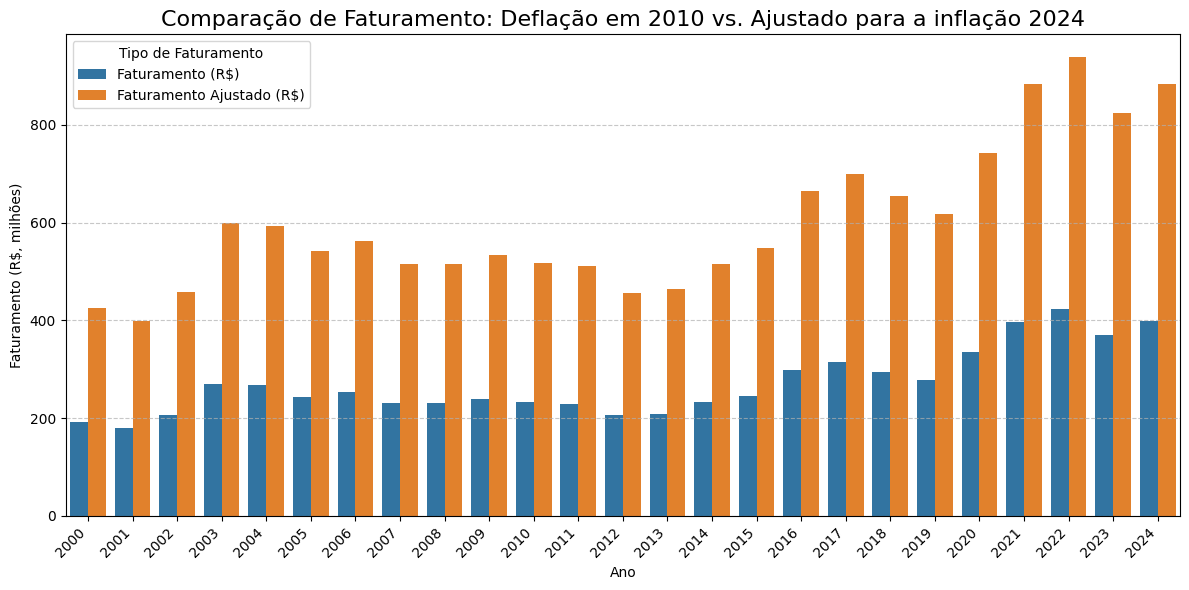

In [209]:
df_long = pd.melt(faturamento_br, id_vars=['Ano'],
                  value_vars=['Faturamento (R$)', 'Faturamento Ajustado (R$)'],
                  var_name='Tipo de Faturamento',
                  value_name='Valor (R$)')

# Crie o gráfico de barras
plt.figure(figsize=(12, 6))

sns.barplot(data=df_long, x='Ano', y=df_long['Valor (R$)']/1000000, hue='Tipo de Faturamento')

# Adicione títulos e rótulos
plt.title('Comparação de Faturamento: Deflação em 2010 vs. Ajustado para a inflação 2024', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Faturamento (R$, milhões)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajuste os rótulos do eixo X para que sejam visíveis
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Com o Faturamento deflacionado para o ano de **2024** conseguimos visualisar a diferença da inflação em 14 anos de diferença, e apesar de não ser com os valores de **2026**, os valores se tornam mais proximos da atualidade.

#### Em qual ano o Brasil mais produziu mel?

##### Extração

Vamos repetir as operações anteriores

In [210]:
producao_br_bruto = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Brasil - 2000 2024.csv')
producao_br_bruto.info()
display(producao_br_bruto)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Sigla   1 non-null      object
 1   Código  1 non-null      int64 
 2   Brasil  1 non-null      object
 3   2000    1 non-null      int64 
 4   2001    1 non-null      int64 
 5   2002    1 non-null      int64 
 6   2003    1 non-null      int64 
 7   2004    1 non-null      int64 
 8   2005    1 non-null      int64 
 9   2006    1 non-null      int64 
 10  2007    1 non-null      int64 
 11  2008    1 non-null      int64 
 12  2009    1 non-null      int64 
 13  2010    1 non-null      int64 
 14  2011    1 non-null      int64 
 15  2012    1 non-null      int64 
 16  2013    1 non-null      int64 
 17  2014    1 non-null      int64 
 18  2015    1 non-null      int64 
 19  2016    1 non-null      int64 
 20  2017    1 non-null      int64 
 21  2018    1 non-null      int64 
 22  2019    1 non-null      int64 

,Sigla,Código,Brasil,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,BR,0,Brasil,21865144,22204675,24028652,30022404,32290462,33749666,36193868,...,37859193,39677393,41695747,42407352,46088931,52493135,55678534,62494156,64164183,67313986


In [211]:
producao_br = pd.melt(producao_br_bruto.drop(columns=['Sigla', 'Código']), id_vars=['Brasil'], var_name='Ano', value_name='Produção (Kg)')
show_head_tail(producao_br)

,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144
1,Brasil,2001,22204675
2,Brasil,2002,24028652
3,Brasil,2003,30022404
4,Brasil,2004,32290462


,Brasil,Ano,Produção (Kg)
20,Brasil,2020,52493135
21,Brasil,2021,55678534
22,Brasil,2022,62494156
23,Brasil,2023,64164183
24,Brasil,2024,67313986


In [212]:
producao_br['Ano'] = melted_faturamento_br['Ano'].astype(int)

##### Resultado

In [213]:
show_max(producao_br,'Produção (Kg)')
show_min(producao_br,'Produção (Kg)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
24,Brasil,2024,67313986


Mínimo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg)
0,Brasil,2000,21865144


**2024** Foi o ano que o Brasil mais Produziu Mel. E percebemos que não é o mesmo ano que teve o maior faturamento.

#### E em qual ano o mel teve seu maior preço?

Pare responder essa pergunta vamos unir as duas tabelas anteriores. Estaremos levando me conta o faturamento ajustado para os cálculos.

In [214]:
mel_br = producao_br.merge(faturamento_br, on=['Brasil', 'Ano'],how='inner')
show_head_tail(mel_br)

,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$)
0,Brasil,2000,21865144,191235448.33,424879235.79
1,Brasil,2001,22204675,179290160.27,398339674.70
2,Brasil,2002,24028652,205953340.51,457578857.31
3,Brasil,2003,30022404,269407150.09,598557982.03
4,Brasil,2004,32290462,267114750.17,593464819.99


,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$)
20,Brasil,2020,52493135,334416942.33,742994126.53
21,Brasil,2021,55678534,397418252.93,882967907.19
22,Brasil,2022,62494156,422375012.79,938415833.55
23,Brasil,2023,64164183,370795279.61,823818054.71
24,Brasil,2024,67313986,397857627.91,883944092.88


In [215]:
show_max(mel_br,'Produção (Kg)')
show_max(mel_br,'Faturamento Ajustado (R$)')

Máximo valor em Produção (Kg)


,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$)
24,Brasil,2024,67313986,397857627.91,883944092.88


Máximo valor em Faturamento Ajustado (R$)


,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$)
22,Brasil,2022,62494156,422375012.79,938415833.55


Aqui criamo o dado que faltava, o preço médio por kilograma.

In [216]:
mel_br['Preço do mel por Kg produzido'] = mel_br['Faturamento Ajustado (R$)']/mel_br['Produção (Kg)']
show_head_tail(mel_br)
show_max(mel_br,'Preço do mel por Kg produzido')

,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,Brasil,2000,21865144,191235448.33,424879235.79,19.43
1,Brasil,2001,22204675,179290160.27,398339674.70,17.94
2,Brasil,2002,24028652,205953340.51,457578857.31,19.04
3,Brasil,2003,30022404,269407150.09,598557982.03,19.94
4,Brasil,2004,32290462,267114750.17,593464819.99,18.38


,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
20,Brasil,2020,52493135,334416942.33,742994126.53,14.15
21,Brasil,2021,55678534,397418252.93,882967907.19,15.86
22,Brasil,2022,62494156,422375012.79,938415833.55,15.02
23,Brasil,2023,64164183,370795279.61,823818054.71,12.84
24,Brasil,2024,67313986,397857627.91,883944092.88,13.13


Máximo valor em Preço do mel por Kg produzido


,Brasil,Ano,Produção (Kg),Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
3,Brasil,2003,30022404,269407150.09,598557982.03,19.94


**2003** foi o ano em que o mel teve seu maior preço por kg, ou seja, mesmo que com o passar do tempo tenha se produzido mais e faturado mais, isso não implica que o preço do mel valorizou. Gráfico abaixo deve demonstrar melhor essa comparação.

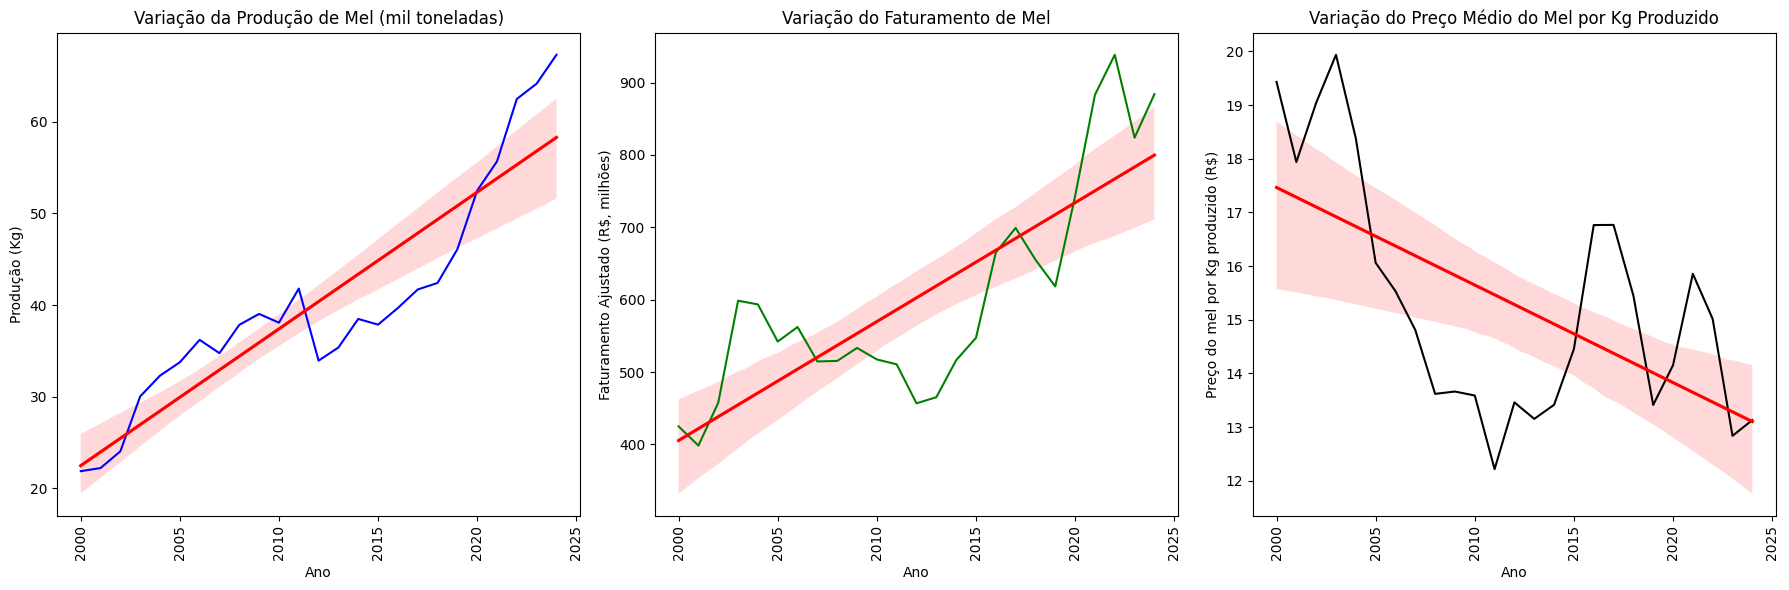

In [217]:
#Convertendo ano para numérico
mel_br['Ano'] = pd.to_numeric(mel_br['Ano'])

# Criar a figura e os 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: Produção (Kg) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y=mel_br['Produção (Kg)']/1000000, ax=axes[0], color='blue')
sns.regplot(data=mel_br, x='Ano', y=mel_br['Produção (Kg)']/1000000, ax=axes[0], color='red', scatter=False, ci=95)
axes[0].set_title('Variação da Produção de Mel (mil toneladas)')
axes[0].set_ylabel('Produção (Kg)')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico 2: Faturamento Ajustado (R$) com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y=mel_br['Faturamento Ajustado (R$)']/1000000, ax=axes[1], color='green')
sns.regplot(data=mel_br, x='Ano', y=mel_br['Faturamento Ajustado (R$)']/1000000, ax=axes[1], color='red', scatter=False, ci=95)  # Convertendo para milhões
axes[1].set_title('Variação do Faturamento de Mel')
axes[1].set_ylabel('Faturamento Ajustado (R$, milhões)')  # Convertendo para milhões
axes[1].tick_params(axis='x', rotation=90)

# Gráfico 3: Preço por Kg com linha de tendência
sns.lineplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='black')
sns.regplot(data=mel_br, x='Ano', y='Preço do mel por Kg produzido', ax=axes[2], color='red', scatter=False, ci=95)
axes[2].set_title('Variação do Preço Médio do Mel por Kg Produzido')
axes[2].set_ylabel('Preço do mel por Kg produzido (R$)')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Com ajuda dos gráficos e suas linhas de tendencia conseguimos ver que apesar da produção do mel ter aumentado, ele é uma produto que tem passado por desvalorização com passar do tempo desdo o inicio do seculo. E apesar de ter tido uma valorização no período de 2016 e 2022, ele não alcançou mais o preço de 2003.

Pontos interessantes nos gráficos são:
1. O declínio da produção no período de 2012, que conforme a noticia do [Agrolink](https://www.agrolink.com.br/noticias/ibge--seca-faz-producao-nacional-de-mel-cair-19--em-2012_184745.html) foi causada pelo período de seca que ocorreu esse ano, e que a recuperação desse período de seca nos anos seguintes pode ter ocasionado a valorização nos anos seguinte, começando em 2013.
2. O outro declínio que aconteceu em 2019, porem esse não estando relacionado a produção de mel, permitindo assim concluir que o o valor do mel e as vendas não são unicamente influenciadas pela produção.


### Regiões

#### Produção

Nesta sessão estaremos utilizando o dataset separado por regiões, que possui a mesma fonte do nacional

In [218]:
producao_rg_bruto = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Regiões - 2000 2024.csv', delimiter=',', header=0)
producao_rg_bruto.drop(columns=['Unnamed: 28'], inplace=True)
producao_rg_bruto

,Sigla,Código,Região,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CO,5,Região Centro-oeste,631704,670833,683466,851928,916724,1097459,1189814,...,1587185,1699572,1971951,1529281,1794364,1856422,1731791,1508226,1801330,1995074
1,N,1,Região Norte,301696,317515,371143,509863,518834,653467,673729,...,948348,905534,802915,890099,1023003,999484,1129658,1252765,1283375,1262999
2,NE,2,Região Nordeste,3748108,3799504,5560006,7967658,10401191,10910916,12102924,...,12305251,10458385,12806050,14126096,15588516,19338339,20244963,24625523,25634101,26527239
3,S,4,Região Sul,12670098,12730601,12277442,15357099,15266363,15815522,16422483,...,14119128,17146509,16480865,16627518,17833466,20391853,22204521,22693682,21837017,22180757
4,SE,3,Região Sudeste,4513538,4686222,5136595,5335856,5187350,5272302,5804918,...,8899281,9467393,9633966,9234358,9849582,9907037,10367601,12413960,13608360,15347917


In [219]:
producao_rg = pd.melt(producao_rg_bruto, id_vars=['Sigla','Código','Região'],var_name='Ano', value_name='Produção (Kg)')
show_head_tail(producao_rg)

,Sigla,Código,Região,Ano,Produção (Kg)
0,CO,5,Região Centro-oeste,2000,631704
1,N,1,Região Norte,2000,301696
2,NE,2,Região Nordeste,2000,3748108
3,S,4,Região Sul,2000,12670098
4,SE,3,Região Sudeste,2000,4513538


,Sigla,Código,Região,Ano,Produção (Kg)
120,CO,5,Região Centro-oeste,2024,1995074
121,N,1,Região Norte,2024,1262999
122,NE,2,Região Nordeste,2024,26527239
123,S,4,Região Sul,2024,22180757
124,SE,3,Região Sudeste,2024,15347917


In [220]:
producao_rg['Ano'] = producao_rg['Ano'].astype(int)
producao_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sigla          125 non-null    object
 1   Código         125 non-null    int64 
 2   Região         125 non-null    object
 3   Ano            125 non-null    int64 
 4   Produção (Kg)  125 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 5.0+ KB


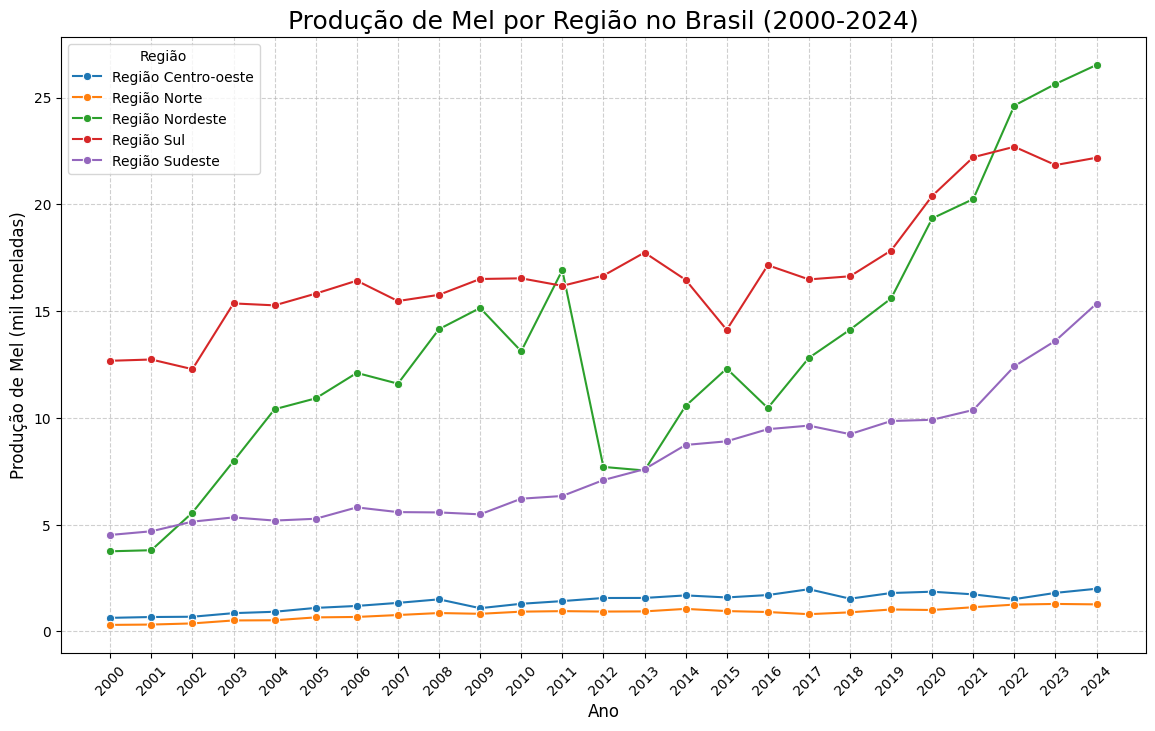

In [221]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(14, 8))
sns.lineplot(data=producao_rg, x='Ano', y='Produção (Kg)', hue='Região', marker='o')

# Adicione título e rótulos
plt.title('Produção de Mel por Região no Brasil (2000-2024)', fontsize=18)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Produção de Mel (mil toneladas)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Formate os rótulos do eixo Y para mostrar em milhões
def millions_formatter(x, pos):
    """Função para formatar os valores do eixo Y em milhões."""
    return f'{x / 1e6:,.0f}'

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(millions_formatter))

# Adicione a legenda
plt.legend(title='Região', loc='upper left')

# Rotacione os rótulos do eixo X para melhor leitura
plt.xticks(producao_rg['Ano'].unique(), rotation=45)

plt.show()

O gráfico acima nos permite visualizar quais são as principais regiões responsáveis pela produção de mel no Brasil desde o início do século XXI. Como esperado, a **Região Sul**, **Nordeste** e **Sudeste** se destacam, sendo as que mais contribuem para o volume total de mel produzido no país.

No entanto, a análise do gráfico revela mais do que apenas a liderança. É possível observar o comportamento distinto de cada uma dessas regiões ao longo do tempo:

* **Região Sul**: Apresenta um crescimento constante na produção, com uma curva ascendente que reflete o fortalecimento do setor apícola na região. É notável que, apesar de flutuações, a tendência geral é de alta. Teve um declínio em 2015 segundo pesquisa, 2 eventos ocorreram esse ano que estão fortemente atreladas a esse declínio:
    * O [El Nino](https://www.climatempo.com.br/noticia/2016/09/22/o-legado-do-el-nino-2015-0199) que é um fenômeno climático natural que aquece as águas do Oceano Pacífico Equatorial.No Brasil, ele causa, principalmente: Secas severas nas regiões Norte e Nordeste, e Aumento de chuvas e inundações na região Sul.
    * A [utilização incorreta de um defensivos agrícolas](https://gauchazh.clicrbs.com.br/campo-e-lavoura/noticia/2015/01/diminuicao-de-250-mil-colmeias-afeta-a-producao-de-mel-no-estado-4679610.html) que resultou na morte de 250 mil colmeias no Rio Grande do Sul.

* **Região Nordeste**: Tem um crescimento significativo, mas com uma alta volatilidade. É possível observar um crescimento inicial forte, seguido por uma queda brusca entre 2011 e 2012, e uma recuperação impressionante a partir de 2017, superando as outras regiões. Essa dinâmica sugere uma sensibilidade maior a fatores externos, como mudanças climáticas.

* **Região Sudeste**:  Apresenta um crescimento constante e estável, sem as grandes oscilações vistas em outras regiões. A produção tem uma tendência de alta clara, mostrando um desenvolvimento sólido e menos suscetível a flutuações.

Além disso, as regiões de menor produção, **Norte** e **Centro-Oeste**, se mantêm em patamares significativamente mais baixos. Ambas apresentam uma produção relativamente estável, sem as grandes oscilações ou tendências de crescimento acentuado vistas nas demais regiões.

Em resumo, o gráfico mostra que, embora três regiões dominem a produção, a dinâmica e a tendência de crescimento de cada uma são únicas, refletindo as particularidades de seus ecossistemas e do cenário econômico ao qual estão expostas.

#### Faturamento

In [222]:
faturamento_rg_bruto = pd.read_csv('data/faturamento mel/Faturamento R$ - Mel de Abelha - Regiões - 2000 2024.csv', delimiter=',', header=0)
faturamento_rg_bruto.drop(columns=['Unnamed: 28'], inplace=True)
faturamento_rg_bruto

,Sigla,Código,Região,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CO,5,Região Centro-oeste,8975.63,9148.69,9291.66,10968.11,11783.07,13488.13,15080.18,...,14459.93,16662.10,18997.61,15137.28,16286.34,17524.29,16893.29,15920.08,18176.43,21209.30
1,N,1,Região Norte,4751.93,4666.12,4557.49,5391.64,5139.73,5618.50,5912.71,...,10171.67,9564.61,7950.04,8623.60,9340.51,10188.03,12477.76,13356.66,14562.89,14624.04
2,NE,2,Região Nordeste,24145.70,19129.65,35948.89,61244.56,64170.96,53510.93,58623.30,...,70387.64,68846.54,84191.99,78691.11,67982.79,103919.34,142004.64,157642.18,124809.21,134751.80
3,S,4,Região Sul,102407.01,97185.55,100390.17,130887.97,127272.56,118434.35,115500.67,...,90632.22,134061.22,131810.86,127283.94,121835.14,136856.54,150592.03,151431.43,136603.69,141192.11
4,SE,3,Região Sudeste,50955.18,49160.14,55765.14,60914.87,58748.43,52944.19,57949.72,...,60661.74,70266.29,71732.12,65190.60,62818.65,65928.76,75450.53,84024.23,76643.06,86080.38


In [223]:
faturamento_rg = pd.melt(faturamento_rg_bruto, id_vars=['Sigla','Código','Região'],var_name='Ano', value_name='Faturamento (R$)')
show_head_tail(faturamento_rg)

,Sigla,Código,Região,Ano,Faturamento (R$)
0,CO,5,Região Centro-oeste,2000,8975.63
1,N,1,Região Norte,2000,4751.93
2,NE,2,Região Nordeste,2000,24145.70
3,S,4,Região Sul,2000,102407.01
4,SE,3,Região Sudeste,2000,50955.18


,Sigla,Código,Região,Ano,Faturamento (R$)
120,CO,5,Região Centro-oeste,2024,21209.30
121,N,1,Região Norte,2024,14624.04
122,NE,2,Região Nordeste,2024,134751.80
123,S,4,Região Sul,2024,141192.11
124,SE,3,Região Sudeste,2024,86080.38


In [224]:
faturamento_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sigla             125 non-null    object 
 1   Código            125 non-null    int64  
 2   Região            125 non-null    object 
 3   Ano               125 non-null    object 
 4   Faturamento (R$)  125 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 5.0+ KB


In [225]:
faturamento_rg['Ano'] = faturamento_rg['Ano'].astype(int)
faturamento_rg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sigla             125 non-null    object 
 1   Código            125 non-null    int64  
 2   Região            125 non-null    object 
 3   Ano               125 non-null    int64  
 4   Faturamento (R$)  125 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 5.0+ KB


In [226]:
ajustar_ipca(faturamento_rg)
display(faturamento_rg)

,Sigla,Código,Região,Ano,Faturamento (R$),Faturamento Ajustado (R$)
0,CO,5,Região Centro-oeste,2000,8975.63,19941683.58
1,N,1,Região Norte,2000,4751.93,10557656.93
2,NE,2,Região Nordeste,2000,24145.70,53645937.53
3,S,4,Região Sul,2000,102407.01,227523776.19
4,SE,3,Região Sudeste,2000,50955.18,113210181.56
...,...,...,...,...,...,...
120,CO,5,Região Centro-oeste,2024,21209.30,47121981.05
121,N,1,Região Norte,2024,14624.04,32491097.77
122,NE,2,Região Nordeste,2024,134751.80,299386133.73
123,S,4,Região Sul,2024,141192.11,313694959.04


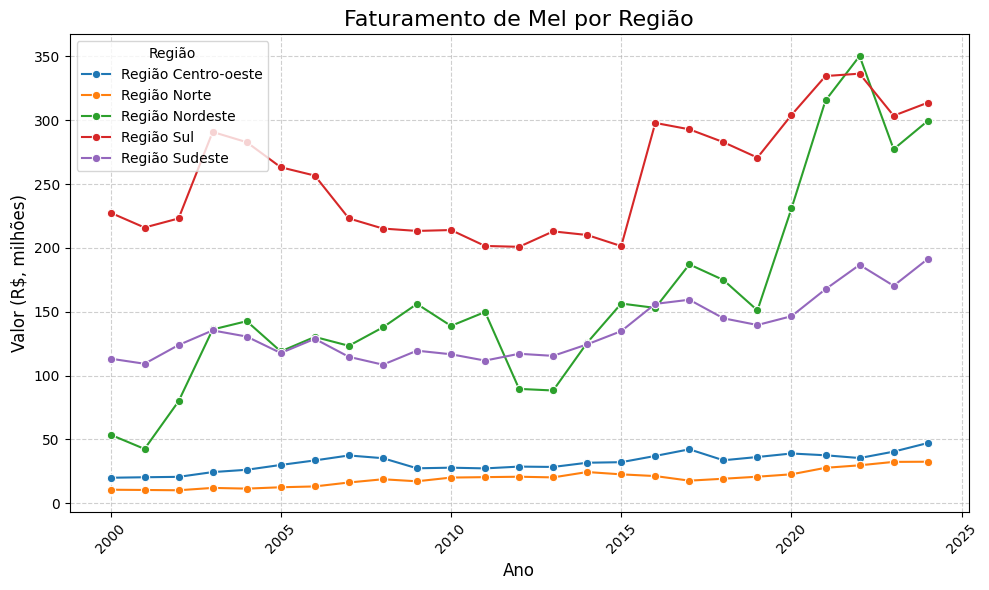

In [227]:

plt.figure(figsize=(10, 6))

# --- Gráfico 1: Faturamento Bruto (Nominal) ---
sns.lineplot(
    data=faturamento_rg,
    x='Ano',
    y=faturamento_rg['Faturamento Ajustado (R$)']/1000000,  # Convertendo para milhões
    hue='Região',
    marker='o',
)
plt.title('Faturamento de Mel por Região', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Valor (R$, milhões)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tick_params(axis='x', rotation=45)
plt.legend(title='Região', loc='upper left')


plt.tight_layout()
plt.show()


Os gráficos de faturamento bruto e ajustado confirmam que as mesmas três regiões — **Sul, Sudeste e Nordeste** — que lideram a produção também dominam o faturamento do mel no Brasil.

No entanto, uma observação crucial é que, apesar da produção do Nordeste superar a do Sul em alguns anos, o faturamento de ambas as regiões se mantém em patamares próximos. Isso sugere que, embora o volume de mel produzido no Nordeste seja significativo, o preço de venda por quilo pode ser menor do que o do Sul, o que o torna menos valorizado no mercado.

Em contrapartida, as flutuações no faturamento da Região Sudeste são notáveis. A queda abrupta em 2012 e a recuperação em 2015 são consistentes com as tendências observadas na análise de produção e preço para o Brasil como um todo. A volatilidade do faturamento no Nordeste, por sua vez, reflete a instabilidade de sua produção, que pode ser mais suscetível a fatores externos como as mudanças climáticas.

Essa análise demonstra que a relação entre produção e faturamento não é direta. A lucratividade do mel é influenciada não apenas pelo volume produzido, mas também pelo preço de mercado, que varia significativamente entre as regiões.

#### E em qual ano o mel teve seu maior preço?

Pare responder essa pergunta vamos unir as duas tabelas anteriores. Estaremos levando me conta o faturamento ajustado para os cálculos.

In [228]:
mel_rg = producao_rg.merge(faturamento_rg, on=['Região', 'Ano'], how='inner')
show_head_tail(mel_rg)

,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$)
0,CO,5,Região Centro-oeste,2000,631704,CO,5,8975.63,19941683.58
1,N,1,Região Norte,2000,301696,N,1,4751.93,10557656.93
2,NE,2,Região Nordeste,2000,3748108,NE,2,24145.70,53645937.53
3,S,4,Região Sul,2000,12670098,S,4,102407.01,227523776.19
4,SE,3,Região Sudeste,2000,4513538,SE,3,50955.18,113210181.56


,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$)
120,CO,5,Região Centro-oeste,2024,1995074,CO,5,21209.30,47121981.05
121,N,1,Região Norte,2024,1262999,N,1,14624.04,32491097.77
122,NE,2,Região Nordeste,2024,26527239,NE,2,134751.80,299386133.73
123,S,4,Região Sul,2024,22180757,S,4,141192.11,313694959.04
124,SE,3,Região Sudeste,2024,15347917,SE,3,86080.38,191249921.30


In [229]:
show_max(mel_rg,'Produção (Kg)')
show_max(mel_rg,'Faturamento Ajustado (R$)')

Máximo valor em Produção (Kg)


,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$)
122,NE,2,Região Nordeste,2024,26527239,NE,2,134751.80,299386133.73


Máximo valor em Faturamento Ajustado (R$)


,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$)
112,NE,2,Região Nordeste,2022,24625523,NE,2,157642.18,350243060.39


Aqui criamo o dado que faltava, o preço médio por kilograma.

In [230]:
mel_rg['Preço do mel por Kg produzido'] = mel_rg['Faturamento Ajustado (R$)']/mel_rg['Produção (Kg)']
show_head_tail(mel_rg)
show_max(mel_rg,'Preço do mel por Kg produzido')

,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
0,CO,5,Região Centro-oeste,2000,631704,CO,5,8975.63,19941683.58,31.57
1,N,1,Região Norte,2000,301696,N,1,4751.93,10557656.93,34.99
2,NE,2,Região Nordeste,2000,3748108,NE,2,24145.70,53645937.53,14.31
3,S,4,Região Sul,2000,12670098,S,4,102407.01,227523776.19,17.96
4,SE,3,Região Sudeste,2000,4513538,SE,3,50955.18,113210181.56,25.08


,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
120,CO,5,Região Centro-oeste,2024,1995074,CO,5,21209.30,47121981.05,23.62
121,N,1,Região Norte,2024,1262999,N,1,14624.04,32491097.77,25.73
122,NE,2,Região Nordeste,2024,26527239,NE,2,134751.80,299386133.73,11.29
123,S,4,Região Sul,2024,22180757,S,4,141192.11,313694959.04,14.14
124,SE,3,Região Sudeste,2024,15347917,SE,3,86080.38,191249921.30,12.46


Máximo valor em Preço do mel por Kg produzido


,Sigla_x,Código_x,Região,Ano,Produção (Kg),Sigla_y,Código_y,Faturamento (R$),Faturamento Ajustado (R$),Preço do mel por Kg produzido
1,N,1,Região Norte,2000,301696,N,1,4751.93,10557656.93,34.99


**2003** foi o ano em que o mel teve seu maior preço por kg, ou seja, mesmo que com o passar do tempo tenha se produzido mais e faturado mais, isso não implica que o preço do mel valorizou. Gráfico abaixo deve demonstrar melhor essa comparação.

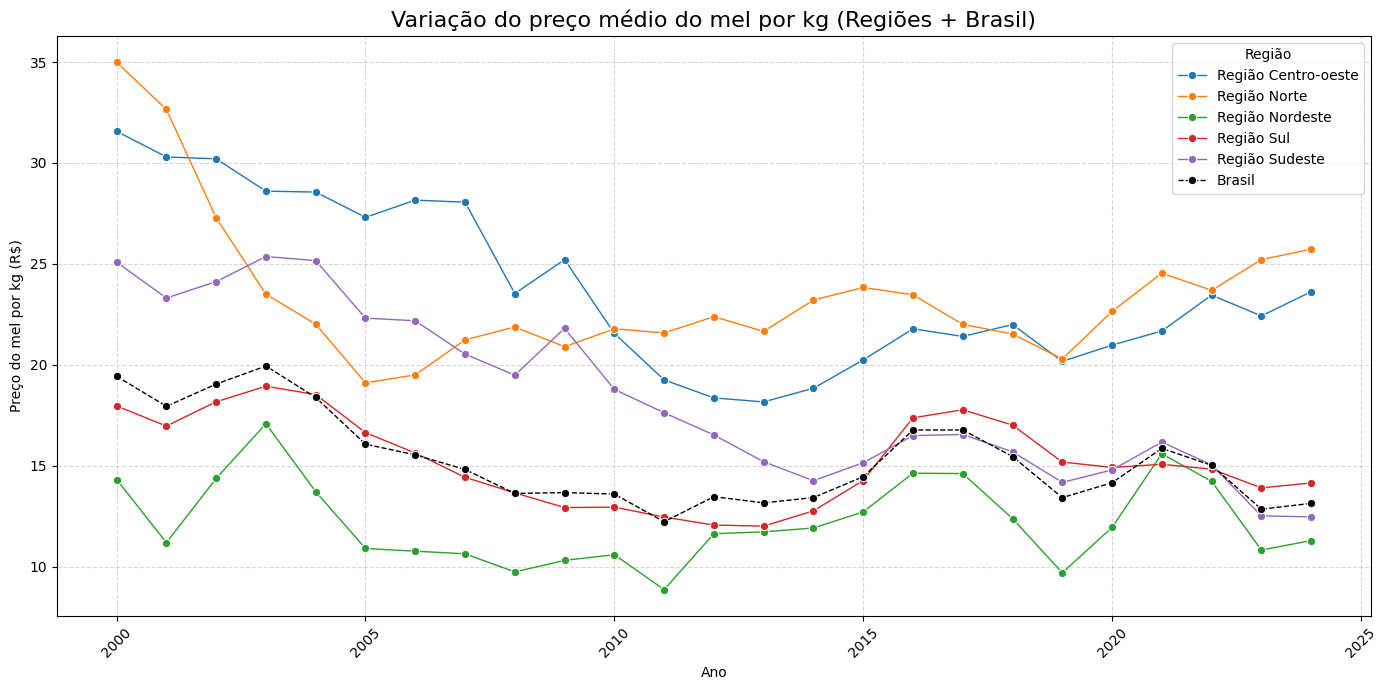

In [231]:
# linhas das regiões com menor destaque
plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=df_price[df_price['Região'] != 'Brasil'],
    x='Ano',
    y='Preço do mel por Kg produzido',
    hue='Região',
    marker='o',
    linewidth=1,
    
)

# linha do Brasil bem destacada
sns.lineplot(
    data=df_price[df_price['Região'] == 'Brasil'],
    x='Ano',
    y='Preço do mel por Kg produzido',
    color='black',
    marker='o',
    linestyle='--',
    linewidth=1,
    label='Brasil',    
    ax=ax
)

plt.title('Variação do preço médio do mel por kg (Regiões + Brasil)', fontsize=16)
plt.xlabel('Ano')
plt.ylabel('Preço do mel por kg (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(title='Região', loc='best')
plt.tight_layout()
plt.show()


Pontos de importantes no grafico:

- Com exceção de um ano, o preço do mel do nordeste possui o mel mais barato entre as regiões, o que justifica o faturamento da ragigão ter sido superior a da região Sul mesmo produzindo mais nos anos de 2023 e 2024. 
- As regiões que menos produzem e faturam (Norte e Centro-Oeste) mantem o preço do mel acima da media nacional.
- O mel da região Sul, que possui a maior produtução e faturamento dos anos 2000 a 2022, possui valor medio muito proxima a media nacional, provavelmente por ser o princial influencia para a media. 

### Estados

* A partir desta sessão estaremos analisando apenas os fatores da produção de mel
* Para essa sessão iremos considerar apenas os estados da região **Sul, Nordeste e Sudeste**, pois com base nos resultados das sessões anteriores são os principais contribuintes para a produção e faturamento de mel no pais.
* E o dataset com estados não alinha possui as regiões de cadas um, então esses valores serão colocados por código utilizando o dicionario abaixo.

In [232]:
#dicionario com a lista de região de cada estado
mapa_regioes = {
    'AC': 'Região Norte',
    'AL': 'Região Nordeste',
    'AP': 'Região Norte',
    'AM': 'Região Norte',
    'BA': 'Região Nordeste',
    'CE': 'Região Nordeste',
    'DF': 'Região Centro-oeste',
    'ES': 'Região Sudeste',
    'GO': 'Região Centro-oeste',
    'MA': 'Região Nordeste',
    'MT': 'Região Centro-oeste',
    'MS': 'Região Centro-oeste',
    'MG': 'Região Sudeste',
    'PA': 'Região Norte',
    'PB': 'Região Nordeste',
    'PR': 'Região Sul',
    'PE': 'Região Nordeste',
    'PI': 'Região Nordeste',
    'RJ': 'Região Sudeste',
    'RN': 'Região Nordeste',
    'RS': 'Região Sul',
    'RO': 'Região Norte',
    'RR': 'Região Norte',
    'SC': 'Região Sul',
    'SP': 'Região Sudeste',
    'SE': 'Região Nordeste',
    'TO': 'Região Norte'
}

#### Produção

In [233]:
producao_es_bruto = pd.read_csv('data/producao mel/Producao Kg - Mel de Abelha - Estados - 2000 2024.csv', delimiter=',')
producao_es_bruto

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 28
0,AC,12,Acre,1800.00,3305.00,3300.00,4483.00,4927.00,4279.00,3704.00,...,4752,5760,5803,4914,4574,6092,8578,9003,8637,NaN
1,AL,27,Alagoas,13941.00,21200.00,14513.00,85696.00,116098.00,183946.00,163885.00,...,168889,216311,264748,331471,372098,403386,423263,515190,538635,NaN
2,AM,13,Amazonas,498.00,505.00,600.00,1018.00,1043.00,1043.00,1085.00,...,33310,30838,32577,32542,32898,34686,33532,34377,67267,NaN
3,AP,16,Amapá,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11379,13458,14782,15585,16521,18199,18245,19378,20054,NaN
4,BA,29,Bahia,520908.00,688105.00,873278.00,1418628.00,1494713.00,1775414.00,2046930.00,...,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4821501,4550258,NaN
5,CE,23,Ceará,654791.00,671873.00,1373377.00,1895918.00,2933133.00,2311626.00,3053053.00,...,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5647799,6058617,NaN
6,DF,53,Distrito Federal,20000.00,14060.00,19060.00,24500.00,26430.00,27479.00,31478.00,...,17660,14325,11069,13826,21944,22423,36739,32532,24080,NaN
7,ES,32,Espírito Santo,176655.00,179725.00,275957.00,312455.00,352626.00,333494.00,403224.00,...,544853,583029,620407,660758,687504,708901,804348,811258,846007,NaN
8,GO,52,Goiás,117371.00,128222.00,155133.00,178845.00,224616.00,244580.00,308005.00,...,432722,319212,337655,331178,329167,366191,316321,402259,443476,NaN
9,MA,21,Maranhão,132478.00,133026.00,158076.00,285863.00,436161.00,517533.00,558775.00,...,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,3362409,NaN


In [234]:
producao_es_bruto.drop(columns=['Unnamed: 28'], inplace=True)
producao_es_bruto['Região'] = producao_es_bruto['Sigla'].map(mapa_regioes)
producao_es_bruto

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Região
0,AC,12,Acre,1800.00,3305.00,3300.00,4483.00,4927.00,4279.00,3704.00,...,4752,5760,5803,4914,4574,6092,8578,9003,8637,Região Norte
1,AL,27,Alagoas,13941.00,21200.00,14513.00,85696.00,116098.00,183946.00,163885.00,...,168889,216311,264748,331471,372098,403386,423263,515190,538635,Região Nordeste
2,AM,13,Amazonas,498.00,505.00,600.00,1018.00,1043.00,1043.00,1085.00,...,33310,30838,32577,32542,32898,34686,33532,34377,67267,Região Norte
3,AP,16,Amapá,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11379,13458,14782,15585,16521,18199,18245,19378,20054,Região Norte
4,BA,29,Bahia,520908.00,688105.00,873278.00,1418628.00,1494713.00,1775414.00,2046930.00,...,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4821501,4550258,Região Nordeste
5,CE,23,Ceará,654791.00,671873.00,1373377.00,1895918.00,2933133.00,2311626.00,3053053.00,...,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5647799,6058617,Região Nordeste
6,DF,53,Distrito Federal,20000.00,14060.00,19060.00,24500.00,26430.00,27479.00,31478.00,...,17660,14325,11069,13826,21944,22423,36739,32532,24080,Região Centro-oeste
7,ES,32,Espírito Santo,176655.00,179725.00,275957.00,312455.00,352626.00,333494.00,403224.00,...,544853,583029,620407,660758,687504,708901,804348,811258,846007,Região Sudeste
8,GO,52,Goiás,117371.00,128222.00,155133.00,178845.00,224616.00,244580.00,308005.00,...,432722,319212,337655,331178,329167,366191,316321,402259,443476,Região Centro-oeste
9,MA,21,Maranhão,132478.00,133026.00,158076.00,285863.00,436161.00,517533.00,558775.00,...,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,3362409,Região Nordeste


In [235]:
# Filtrar apenas estados das regiões Sul, Sudeste e Nordeste
estados_pesquisa = producao_es_bruto[producao_es_bruto['Região'].isin(['Região Sul', 'Região Sudeste', 'Região Nordeste'])]
display(estados_pesquisa)

,Sigla,Código,Estado,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Região
1,AL,27,Alagoas,13941.00,21200.00,14513.00,85696.00,116098.00,183946.00,163885.00,...,168889,216311,264748,331471,372098,403386,423263,515190,538635,Região Nordeste
4,BA,29,Bahia,520908.00,688105.00,873278.00,1418628.00,1494713.00,1775414.00,2046930.00,...,3579469,3407361,3039843,3708261,5017609,4588657,5029007,4821501,4550258,Região Nordeste
5,CE,23,Ceará,654791.00,671873.00,1373377.00,1895918.00,2933133.00,2311626.00,3053053.00,...,1149390,1776231,2113192,2677489,3897743,3754811,5398805,5647799,6058617,Região Nordeste
7,ES,32,Espírito Santo,176655.00,179725.00,275957.00,312455.00,352626.00,333494.00,403224.00,...,544853,583029,620407,660758,687504,708901,804348,811258,846007,Região Sudeste
9,MA,21,Maranhão,132478.00,133026.00,158076.00,285863.00,436161.00,517533.00,558775.00,...,1710718,2355873,2261672,2337026,2477212,2381960,2572768,3186374,3362409,Região Nordeste
10,MG,31,Minas Gerais,2100982.00,2068024.00,2408189.00,2194385.00,2134370.00,2207925.00,2482174.00,...,4906589,4560848,4077462,4226823,4103316,4584133,6164784,6862976,7325594,Região Sudeste
14,PB,25,Paraíba,30036.00,32364.00,41228.00,58643.00,73031.00,87607.00,263964.00,...,156563,156438,199227,199603,278910,310721,357594,364192,403779,Região Nordeste
15,PE,26,Pernambuco,344325.00,320109.00,575016.00,653418.00,883196.00,1028772.00,1161579.00,...,372100,255809,616426,769814,938426,1248305,1658340,1200054,1616366,Região Nordeste
16,PI,22,Piauí,1862739.00,1741078.00,2221510.00,3146358.00,3894437.00,4497392.00,4195910.00,...,3048800,4404654,5224833,5024344,5672514,6875615,8321923,8829805,8614225,Região Nordeste
17,PR,41,Paraná,2870955.00,2925432.00,2843995.00,4068191.00,4348301.00,4462022.00,4612372.00,...,5993565,5962813,6307107,7202539,7890115,8418363,8799569,8488483,9822960,Região Sul


In [238]:
producao_es = pd.melt(estados_pesquisa, id_vars=['Sigla','Código','Região','Estado'],var_name='Ano', value_name='Produção (Kg)')
show_head_tail(producao_es)

,Sigla,Código,Região,Estado,Ano,Produção (Kg)
0,AL,27,Região Nordeste,Alagoas,2000,13941.00
1,BA,29,Região Nordeste,Bahia,2000,520908.00
2,CE,23,Região Nordeste,Ceará,2000,654791.00
3,ES,32,Região Sudeste,Espírito Santo,2000,176655.00
4,MA,21,Região Nordeste,Maranhão,2000,132478.00


,Sigla,Código,Região,Estado,Ano,Produção (Kg)
395,RN,24,Região Nordeste,Rio Grande do Norte,2024,1190489.00
396,RS,43,Região Sul,Rio Grande do Sul,2024,8064092.00
397,SC,42,Região Sul,Santa Catarina,2024,4293705.00
398,SE,28,Região Nordeste,Sergipe,2024,192461.00
399,SP,35,Região Sudeste,São Paulo,2024,6772329.00


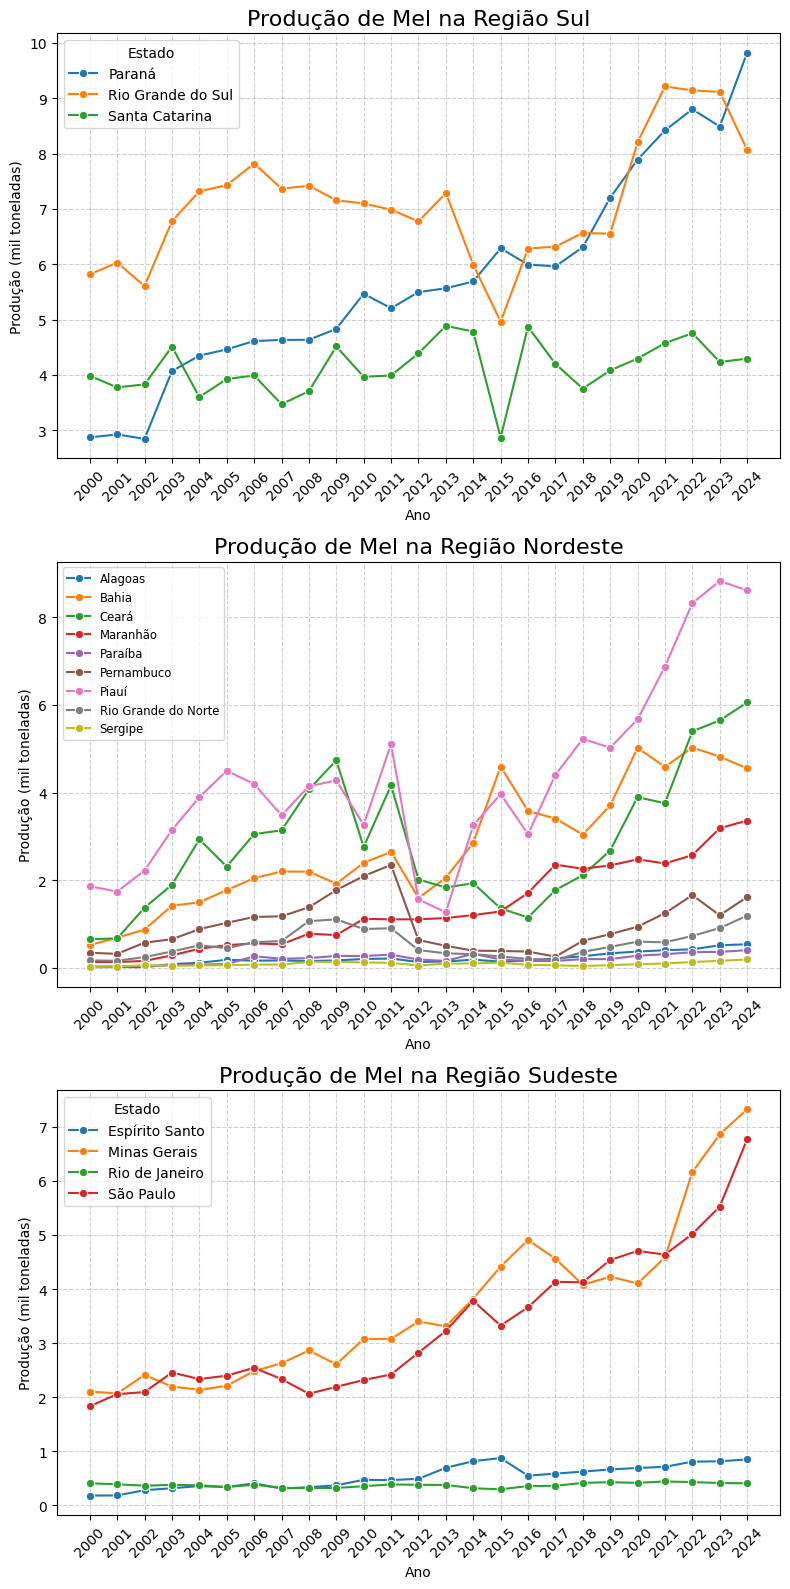

In [243]:
fig, axes = plt.subplots(3, 1, figsize=(8, 16))

# --- GRÁFICO 1: REGIÃO SUL ---
# Filtre o DataFrame para a Região Sul
df_sul = producao_es[producao_es['Região'] == 'Região Sul']

# Plote o gráfico
sns.lineplot(
    data=df_sul,
    x='Ano',
    y=producao_es['Produção (Kg)']/1000000,
    hue='Estado',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Produção de Mel na Região Sul', fontsize=16)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Produção (mil toneladas)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].tick_params(axis='x', rotation=45)

# --- GRÁFICO 2: REGIÃO NORDESTE ---
# Filtre o DataFrame para a Região Nordeste
df_nordeste = producao_es[producao_es['Região'] == 'Região Nordeste']

# Plote o gráfico
sns.lineplot(
    data=df_nordeste,
    x='Ano',
    y=producao_es['Produção (Kg)']/1000000,
    hue='Estado',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Produção de Mel na Região Nordeste', fontsize=16)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Produção (mil toneladas)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', fontsize='small') # Legenda menor para evitar sobreposição

# --- GRÁFICO 3: REGIÃO SUDESTE ---
# Filtre o DataFrame para a Região Sudeste
df_sudeste = producao_es[producao_es['Região'] == 'Região Sudeste']

# Plote o gráfico
sns.lineplot(
    data=df_sudeste,
    x='Ano',
    y=producao_es['Produção (Kg)']/1000000,
    hue='Estado',
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Produção de Mel na Região Sudeste', fontsize=16)
axes[2].set_xlabel('Ano')
axes[2].set_ylabel('Produção (mil toneladas)')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].tick_params(axis='x', rotation=45)

# Otimize o layout para evitar sobreposição de elementos
plt.tight_layout()
plt.show()

Análise Aprofundada da Produção por Estado
A análise detalhada por estado confirma que a produção de mel é muito mais *volátil* em nível estadual do que em nível regional. Dentro das três principais regiões produtoras, cada estado tem uma dinâmica própria, influenciada por fatores locais.

* **Região Sul**: O gráfico do **Sul** mostra um panorama de crescimento notável, com a produção do Paraná (linha azul) apresentando uma forte tendência de alta a partir de 2003. Em 2014, o **Paraná** alcançou um nível de produção muito próximo ao do **Rio Grande do Sul**, e tem se mantido competitivo desde então. O **Rio Grande do Sul e Santa Catarina** também exibem crescimento, mas com flutuações mais evidentes. O destaque, no entanto, fica para o acentuado declínio de produção em 2015. Esse evento pode ser atribuído a uma combinação de fatores: o intenso **El Niño** que causou chuvas torrenciais, prejudicando a florada e a atividade das abelhas, e o uso incorreto de **defensivos agrícolas** que resultou na morte em massa de colmeias na região. E por ultimo em 2024 percebemos uma queda acentuada na produção do **Rio Grande do Sul** causadas pelas enchentes que foram classificadas como "a maior catástrofe climática" da história do estado.

* **Região Nordeste**: O impacto da **seca de 2012** é claramente visível, afetando os quatro maiores produtores de 2011: **Piauí, Ceará, Bahia e Pernambuco**. Os gráficos mostram uma queda acentuada na produção de todos esses estados no período. É notável que, em 2023, Pernambuco ainda não conseguiu recuperar o nível de produção que tinha antes da seca. A produção da Paraíba, por sua vez, manteve-se relativamente estável, sem um crescimento significativo, indicando a falta de avanço do setor no estado.

* **Região Sudeste**: A produção no Sudeste, liderada por Minas Gerais e São Paulo, mostra uma tendência de crescimento consistente e notável ao longo do tempo. Embora a produção total da região tenha flutuado em alguns anos, a análise por estado revela que os dois maiores produtores da região continuaram expandindo suas produções de mel de forma contínua.